In [2]:
!pip install -q shap xgboost statsmodels --upgrade


PHASE 1 | Pre-Flight Validation
[PRE-FLIGHT | HOURLY] N=21937 | Range: 2022-08-01 00:00:00 -> 2025-01-31 00:00:00
[PRE-FLIGHT | DAILY] Contiguity OK: 908 consecutive days.
[PRE-FLIGHT | DAILY] Dropped zero-variance 'aod_missing'.
[PRE-FLIGHT | DAILY] Final N=907 after shift(-1).

PHASE 2A | Deterministic Diurnal Aggregation
[DIURNAL AGG] Shape: (915, 8)

PHASE 2B | Model A: Seasonal Nowcasting
[MODEL A | Winter      ] N=  5809 | MAE=5.93 | RMSE=8.94
[MODEL A | PreMonsoon  ] N=  4416 | MAE=4.33 | RMSE=6.15
[MODEL A | Monsoon     ] N=  7320 | MAE=2.16 | RMSE=3.74
[MODEL A | PostMonsoon ] N=  4392 | MAE=5.35 | RMSE=8.13

PHASE 3 | Model B: 3-Model T+24h Benchmark
[MODEL B] Features used (25): ['pm2_5_mean', 'pm2_5_max', 'pm25_lag7', 'aod_extinction', 'merra2_surf_pm25_ugm3', 'blh_mean', 'wind_u_mean', 'wind_v_mean', 'wind_speed_mean', 'temperature_mean', 'rh_mean', 'precip_sum', 'is_winter', 'is_premonsoon', 'is_monsoon', 'is_postmonsoon', 'blh_x_winter', 'blh_x_monsoon', 'wind_x_winter',

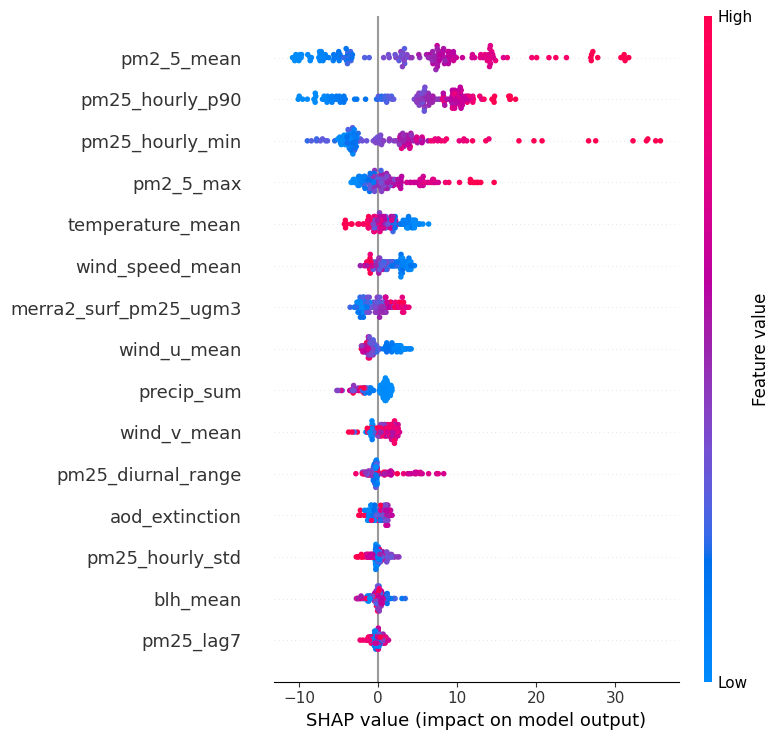

[SHAP] Saved -> ./shap_summary_v3.png

PHASE 5 | Evaluation Plots


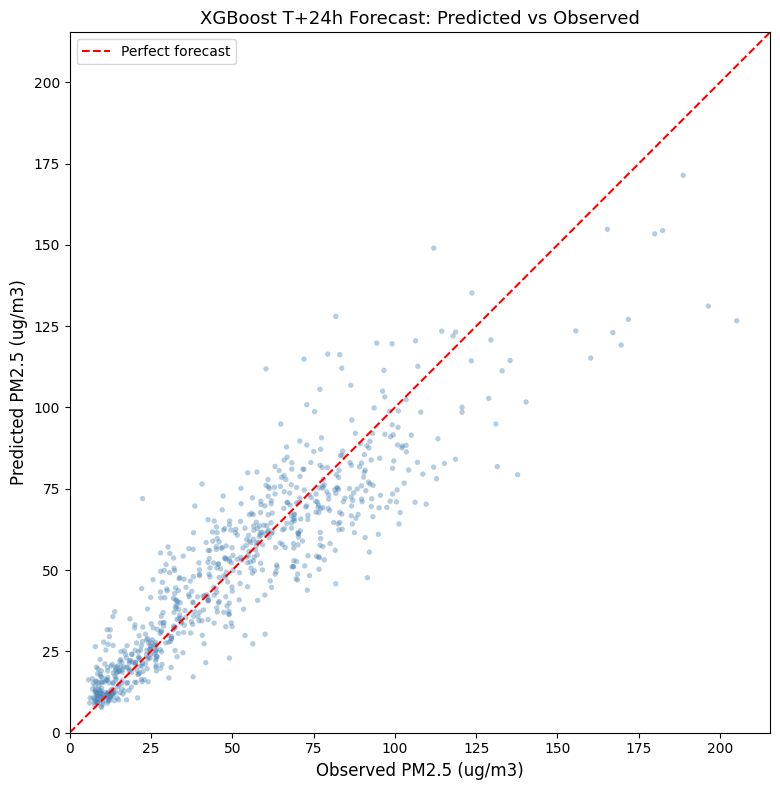

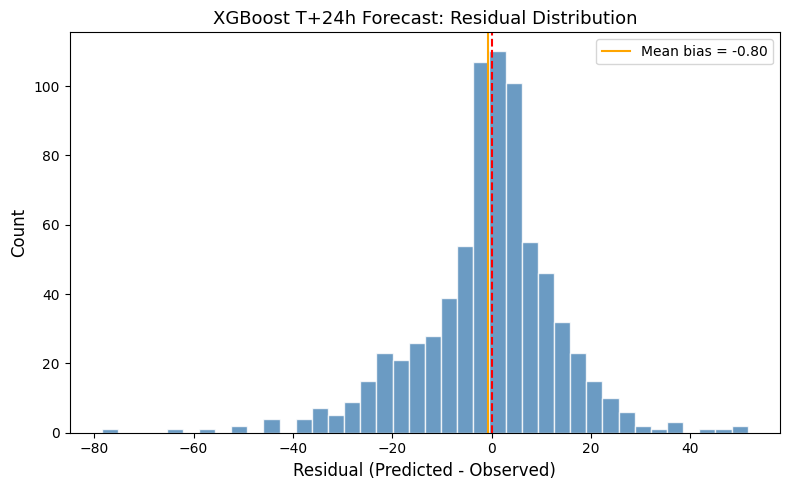

[EVAL] Scatter -> ./eval_scatter.png
[EVAL] Residuals -> ./eval_residuals.png
[EVAL] Mean bias: -0.80, Std: 14.15

PHASE 6 | Diagnostic Tests (DM / Ljung-Box / Spearman / Peak-Event)

  BLOCK 6A | Diebold-Mariano Forecast Comparison Test
  H0: Two models have equal predictive accuracy
  H1: Two models have different predictive accuracy (two-sided test)
  Sample size: N=755 (NaN-masked, all validation folds)
------------------------------------------------------------
  Test 1: Full XGBoost vs Naive Persistence
    DM Statistic : -0.5617
    p-value      : 0.5745
    Result       : ⚠️  NOT SIGNIFICANT (p=0.574) — the accuracy difference is not statistically distinguishable from chance.
    Interpretation: Dhaka's high autocorrelation makes persistence a formidable baseline. The paper's Q1 value lies in SHAP interpretability
                    and the RAG policy bridge, not in raw forecast gain.
------------------------------------------------------------
  Test 2: Full XGBoost vs AR-On

In [4]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  MULTI-RESOLUTION AQI FORECASTING ENGINE — V3 (Q1 PUBLICATION)   ║
# ║  3-Model Benchmark + Diurnal Injection + SHAP + Evaluation       ║
# ║  PM2.5 │ Dhaka, Bangladesh │ MERRA-2 + Ground Fusion             ║
# ╚══════════════════════════════════════════════════════════════════╝
#
# OPERATIONAL NOTE: This pipeline issues T+24h forecasts at END-OF-DAY.
# Same-day features are fully observable at forecast issuance time.
#
# TO RUN IN COLAB:
#   Cell 1: !pip install -q shap xgboost statsmodels --upgrade
#   Cell 2: from google.colab import drive; drive.mount('/content/drive')
#   Cell 3: Paste this entire file and run.

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.impute import SimpleImputer
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox

DATE_CAP = '2025-01-31'

SEASON_MAP = {
    'Winter':      [12, 1, 2],
    'PreMonsoon':  [3, 4, 5],
    'Monsoon':     [6, 7, 8, 9],
    'PostMonsoon': [10, 11],
}

# ════════════════════════════════════════════════════════════════════
# BLOCK 1: PRE-FLIGHT VALIDATION
# ════════════════════════════════════════════════════════════════════

def load_hourly(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, parse_dates=['datetime']).sort_values('datetime')
    df.rename(columns={'datetime': 'timestamp'}, inplace=True)
    df = df[df['timestamp'] <= DATE_CAP].reset_index(drop=True)
    print(f"[PRE-FLIGHT | HOURLY] N={len(df)} | "
          f"Range: {df['timestamp'].min()} -> {df['timestamp'].max()}")
    return df


def load_daily(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, parse_dates=['date']).sort_values('date').reset_index(drop=True)
    df = df[df['date'] <= DATE_CAP].copy()

    # Contiguity assertion — guarantees shift(-1) maps to exactly tomorrow
    expected = (df['date'].max() - df['date'].min()).days + 1
    actual = len(df)
    assert expected == actual, (
        f"ABORT: Non-contiguous. Expected {expected} days, got {actual}.")
    print(f"[PRE-FLIGHT | DAILY] Contiguity OK: {actual} consecutive days.")

    # T+24h target
    df['PM25_Target'] = df['pm2_5_mean'].shift(-1)
    df = df.dropna(subset=['PM25_Target']).reset_index(drop=True)

    # Drop zero-variance columns
    if 'aod_missing' in df.columns and df['aod_missing'].var() < 1e-9:
        df.drop(columns=['aod_missing'], inplace=True)
        print("[PRE-FLIGHT | DAILY] Dropped zero-variance 'aod_missing'.")

    print(f"[PRE-FLIGHT | DAILY] Final N={len(df)} after shift(-1).")
    return df


def engineer_seasonal_flags(df, date_col):
    months = pd.to_datetime(df[date_col]).dt.month
    df['is_winter']      = months.isin(SEASON_MAP['Winter']).astype(int)
    df['is_premonsoon']  = months.isin(SEASON_MAP['PreMonsoon']).astype(int)
    df['is_monsoon']     = months.isin(SEASON_MAP['Monsoon']).astype(int)
    df['is_postmonsoon'] = months.isin(SEASON_MAP['PostMonsoon']).astype(int)

    if 'blh_mean' in df.columns:
        df['blh_x_winter']  = df['blh_mean'] * df['is_winter']
        df['blh_x_monsoon'] = df['blh_mean'] * df['is_monsoon']
    if 'wind_speed_mean' in df.columns:
        df['wind_x_winter'] = df['wind_speed_mean'] * df['is_winter']
    if 'boundary_layer_height' in df.columns:
        df['blh_x_winter']  = df['boundary_layer_height'] * df['is_winter']
        df['blh_x_monsoon'] = df['boundary_layer_height'] * df['is_monsoon']
    if 'wind_speed_10m' in df.columns:
        df['wind_x_winter'] = df['wind_speed_10m'] * df['is_winter']

    for col in ['season', 'Season', 'SEASON']:
        if col in df.columns:
            df.drop(columns=[col], inplace=True)
    return df


# ════════════════════════════════════════════════════════════════════
# BLOCK 2A: RAW DIURNAL AGGREGATION (replaces OOF bridge)
# ════════════════════════════════════════════════════════════════════

def aggregate_raw_hourly_to_daily(df_hourly):
    df = df_hourly.copy()
    df['date'] = df['timestamp'].dt.strftime('%Y-%m-%d')

    daily_agg = df.groupby('date')['pm2_5'].agg(
        pm25_hourly_max   = 'max',
        pm25_hourly_min   = 'min',
        pm25_hourly_std   = 'std',
        pm25_hourly_p90   = lambda s: s.quantile(0.90),
        pm25_hourly_count = 'count',
    ).reset_index()

    daily_agg['pm25_diurnal_range'] = (
        daily_agg['pm25_hourly_max'] - daily_agg['pm25_hourly_min'])
    daily_agg['pm25_hour_coverage_ok'] = (
        daily_agg['pm25_hourly_count'] >= 18).astype(int)

    print(f"[DIURNAL AGG] Shape: {daily_agg.shape}")
    return daily_agg


# ════════════════════════════════════════════════════════════════════
# BLOCK 2B: MODEL A — INDEPENDENT SEASONAL NOWCASTING
# ════════════════════════════════════════════════════════════════════

HOURLY_FEATURES = [
    'hour', 'day_of_week', 'month',
    'temperature_2m', 'relative_humidity_2m', 'wind_speed_10m',
    'wind_direction_10m', 'boundary_layer_height', 'wind_u', 'wind_v',
    'is_winter', 'is_premonsoon', 'is_monsoon', 'is_postmonsoon',
    'pm25_lag1', 'pm25_lag24',
]


def run_model_a(df_hourly):
    df = df_hourly.copy()
    df['hour']        = df['timestamp'].dt.hour
    df['day_of_week'] = df['timestamp'].dt.dayofweek
    df['month']       = df['timestamp'].dt.month
    df = engineer_seasonal_flags(df, 'timestamp')

    tss = TimeSeriesSplit(n_splits=5)
    results = {}

    for name, months_in in SEASON_MAP.items():
        df_s = df[df['timestamp'].dt.month.isin(months_in)].copy()
        if len(df_s) < 500:
            continue
        feats = [c for c in HOURLY_FEATURES if c in df_s.columns]
        X, y = df_s[feats].values, df_s['pm2_5'].values

        maes, rmses = [], []
        for tr, va in tss.split(X):
            m = xgb.XGBRegressor(
                n_estimators=500, learning_rate=0.05, max_depth=6,
                subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
                tree_method='hist', random_state=42, n_jobs=-1,
                early_stopping_rounds=30)
            m.fit(X[tr], y[tr], eval_set=[(X[va], y[va])], verbose=False)
            p = m.predict(X[va])
            maes.append(mean_absolute_error(y[va], p))
            rmses.append(np.sqrt(mean_squared_error(y[va], p)))

        results[name] = {'n': len(df_s),
                         'mae': f"{np.mean(maes):.2f}+/-{np.std(maes):.2f}",
                         'rmse': f"{np.mean(rmses):.2f}"}
        print(f"[MODEL A | {name:<12}] N={len(df_s):>6} | "
              f"MAE={np.mean(maes):.2f} | RMSE={np.mean(rmses):.2f}")
    return results


# ════════════════════════════════════════════════════════════════════
# BLOCK 3: MODEL B — DAILY T+24h 3-MODEL BENCHMARK
# ════════════════════════════════════════════════════════════════════

DAILY_FEATURES = [
    'pm2_5_mean', 'pm2_5_max', 'pm25_lag7',
    'aod_extinction', 'merra2_surf_pm25_ugm3',
    'blh_mean', 'wind_u_mean', 'wind_v_mean', 'wind_speed_mean',
    'temperature_mean', 'rh_mean', 'precip_sum',
    'is_winter', 'is_premonsoon', 'is_monsoon', 'is_postmonsoon',
    'blh_x_winter', 'blh_x_monsoon', 'wind_x_winter',
    'pm25_hourly_max', 'pm25_hourly_min', 'pm25_hourly_std',
    'pm25_hourly_p90', 'pm25_diurnal_range', 'pm25_hour_coverage_ok',
]


def _build_models():
    """Returns dict of model_name -> (constructor, needs_imputation)."""
    return {
        'XGBoost': (
            lambda: xgb.XGBRegressor(
                n_estimators=600, learning_rate=0.03, max_depth=5,
                subsample=0.75, colsample_bytree=0.75, min_child_weight=8,
                gamma=0.10, tree_method='hist', random_state=42, n_jobs=-1,
                early_stopping_rounds=40),
            False  # XGBoost handles NaN natively
        ),
        'RandomForest': (
            lambda: RandomForestRegressor(
                n_estimators=400, max_depth=8, min_samples_leaf=10,
                random_state=42, n_jobs=-1),
            True   # RF cannot handle NaN — must impute per fold
        ),
        'Ridge': (
            lambda: Ridge(alpha=1.0),
            True   # Linear model — must impute per fold
        ),
    }


def run_model_b(df_daily, df_diurnal):
    df_daily = df_daily.copy()
    df_daily['date'] = pd.to_datetime(df_daily['date']).dt.strftime('%Y-%m-%d')
    df_diurnal['date'] = df_diurnal['date'].astype(str)

    n_before = len(df_daily)
    df = df_daily.merge(df_diurnal, on='date', how='left')
    assert len(df) == n_before, "ABORT: Merge mutated row count."

    df = engineer_seasonal_flags(df, 'date')

    feats = [c for c in DAILY_FEATURES if c in df.columns]
    feats = [c for c in feats if df[c].dtype != object]
    X_full = df[feats].values
    y_full = df['PM25_Target'].values

    print(f"[MODEL B] Features used ({len(feats)}): {feats}")

    tss = TimeSeriesSplit(n_splits=5)
    models_cfg = _build_models()
    all_results = {}
    xgb_final_model = None
    xgb_final_Xval = None
    # Store all predictions for evaluation plots
    all_y_true, all_y_pred_xgb = [], []
    # DM-aligned arrays (NaN-masked, for diagnostic tests)
    all_y_true_dm, all_y_pred_dm, all_y_pers_dm = [], [], []

    for model_name, (constructor, needs_impute) in models_cfg.items():
        fold_log = []
        print(f"\n{'='*60}")
        print(f"  {model_name} — 5-Fold TimeSeriesSplit")
        print(f"{'='*60}")
        print(f"{'FOLD':<6}{'N':<7}{'MAE':<9}{'RMSE':<9}{'R2':<8}"
              f"{'PERS_MAE':<10}{'SKILL%':<8}")
        print(f"{'-'*60}")

        for k, (tr, va) in enumerate(tss.split(X_full)):
            X_tr, X_va = X_full[tr].copy(), X_full[va].copy()
            y_tr, y_va = y_full[tr], y_full[va]

            # Fold-internal imputation for models that can't handle NaN
            if needs_impute:
                imp = SimpleImputer(strategy='median')
                X_tr = imp.fit_transform(X_tr)
                X_va = imp.transform(X_va)

            m = constructor()
            if model_name == 'XGBoost':
                m.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
            else:
                m.fit(X_tr, y_tr)

            pred = m.predict(X_va)
            mae  = mean_absolute_error(y_va, pred)
            rmse = np.sqrt(mean_squared_error(y_va, pred))
            r2   = r2_score(y_va, pred)

            # Persistence baseline
            y_pers = df.iloc[va]['pm2_5_mean'].values
            mask = ~np.isnan(y_pers)
            mae_p = mean_absolute_error(y_va[mask], y_pers[mask])
            skill = (1.0 - mae / mae_p) * 100

            print(f"{k+1:<6}{len(va):<7}{mae:<9.2f}{rmse:<9.2f}"
                  f"{r2:<8.3f}{mae_p:<10.2f}{skill:<8.1f}")

            fold_log.append(dict(fold=k+1, mae=mae, rmse=rmse,
                                 r2=r2, mae_pers=mae_p, skill=skill))

            if model_name == 'XGBoost':
                xgb_final_model = m
                xgb_final_Xval = X_full[va]
                all_y_true.extend(y_va)
                all_y_pred_xgb.extend(pred)
                # Collect DM-aligned arrays (apply same NaN mask for alignment)
                all_y_true_dm.extend(y_va[mask])
                all_y_pred_dm.extend(pred[mask])
                all_y_pers_dm.extend(y_pers[mask])

        dl = pd.DataFrame(fold_log)
        print(f"{'-'*60}")
        print(f"{'MEAN':<6}{'':<7}{dl['mae'].mean():<9.2f}"
              f"{dl['rmse'].mean():<9.2f}{dl['r2'].mean():<8.3f}"
              f"{dl['mae_pers'].mean():<10.2f}{dl['skill'].mean():<8.1f}")
        all_results[model_name] = dl

    # Print final comparison table
    print(f"\n{'='*60}")
    print("  FINAL MODEL COMPARISON (Mean across 5 folds)")
    print(f"{'='*60}")
    print(f"{'Model':<16}{'MAE':<9}{'RMSE':<9}{'R2':<8}{'Skill%':<8}")
    print(f"{'-'*60}")
    for mn, dl in all_results.items():
        print(f"{mn:<16}{dl['mae'].mean():<9.2f}"
              f"{dl['rmse'].mean():<9.2f}{dl['r2'].mean():<8.3f}"
              f"{dl['skill'].mean():<8.1f}")
    print(f"{'='*60}\n")

    return dict(
        all_results=all_results,
        xgb_model=xgb_final_model,
        xgb_Xval=xgb_final_Xval,
        feature_names=feats,
        y_true=np.array(all_y_true),
        y_pred=np.array(all_y_pred_xgb),
        y_true_dm=np.array(all_y_true_dm),
        y_pred_dm=np.array(all_y_pred_dm),
        y_pers_dm=np.array(all_y_pers_dm),
    )


# ════════════════════════════════════════════════════════════════════
# BLOCK 3B: ABLATION STUDY — INCREMENTAL FEATURE GROUP CONTRIBUTION
# ════════════════════════════════════════════════════════════════════
#
# PURPOSE: Prove each feature group adds predictive value incrementally.
# This is required for Q1 peer review — reviewers will ask "did diurnal
# features actually help, or did XGBoost ignore them?"
#
# Groups tested on XGBoost only (the benchmark winner), same 5-fold
# TimeSeriesSplit, same hyperparameters as the main benchmark.
#
# G1 | AR Only:          autoregressive PM2.5 lags only
# G2 | AR + Meteo:       add meteorological + seasonal features
# G3 | AR + Meteo + Sat: add NASA MERRA-2 satellite products
# G4 | Full Model:       add deterministic diurnal micro-physics
# ════════════════════════════════════════════════════════════════════

ABLATION_GROUPS = {
    'G1_AR_Only': [
        'pm2_5_mean', 'pm2_5_max', 'pm25_lag7',
    ],
    'G2_AR_Meteo': [
        'pm2_5_mean', 'pm2_5_max', 'pm25_lag7',
        'blh_mean', 'wind_u_mean', 'wind_v_mean', 'wind_speed_mean',
        'temperature_mean', 'rh_mean', 'precip_sum',
        'is_winter', 'is_premonsoon', 'is_monsoon', 'is_postmonsoon',
        'blh_x_winter', 'blh_x_monsoon', 'wind_x_winter',
    ],
    'G3_AR_Meteo_Satellite': [
        'pm2_5_mean', 'pm2_5_max', 'pm25_lag7',
        'blh_mean', 'wind_u_mean', 'wind_v_mean', 'wind_speed_mean',
        'temperature_mean', 'rh_mean', 'precip_sum',
        'is_winter', 'is_premonsoon', 'is_monsoon', 'is_postmonsoon',
        'blh_x_winter', 'blh_x_monsoon', 'wind_x_winter',
        'aod_extinction', 'merra2_surf_pm25_ugm3',
    ],
    'G4_Full_Model': [
        'pm2_5_mean', 'pm2_5_max', 'pm25_lag7',
        'blh_mean', 'wind_u_mean', 'wind_v_mean', 'wind_speed_mean',
        'temperature_mean', 'rh_mean', 'precip_sum',
        'is_winter', 'is_premonsoon', 'is_monsoon', 'is_postmonsoon',
        'blh_x_winter', 'blh_x_monsoon', 'wind_x_winter',
        'aod_extinction', 'merra2_surf_pm25_ugm3',
        'pm25_hourly_max', 'pm25_hourly_min', 'pm25_hourly_std',
        'pm25_hourly_p90', 'pm25_diurnal_range', 'pm25_hour_coverage_ok',
    ],
}


def run_ablation(df_daily, df_diurnal):
    """Run XGBoost on 4 incremental feature groups to prove each group adds value.
    Uses identical hyperparameters and TimeSeriesSplit as the main benchmark.
    """
    df_daily = df_daily.copy()
    df_daily['date'] = pd.to_datetime(df_daily['date']).dt.strftime('%Y-%m-%d')
    df_diurnal['date'] = df_diurnal['date'].astype(str)
    df = df_daily.merge(df_diurnal, on='date', how='left')
    df = engineer_seasonal_flags(df, 'date')
    y_full = df['PM25_Target'].values

    tss = TimeSeriesSplit(n_splits=5)

    def _xgb():
        return xgb.XGBRegressor(
            n_estimators=600, learning_rate=0.03, max_depth=5,
            subsample=0.75, colsample_bytree=0.75, min_child_weight=8,
            gamma=0.10, tree_method='hist', random_state=42, n_jobs=-1,
            early_stopping_rounds=40)

    print(f"\n{'='*60}")
    print("  ABLATION STUDY — Incremental Feature Group Contribution")
    print(f"  XGBoost | 5-Fold TimeSeriesSplit | Same hyperparameters")
    print(f"{'='*60}")
    print(f"{'Group':<28}{'N_feats':<9}{'MAE':<9}{'RMSE':<9}{'R2':<8}{'ΔMAE':>7}")
    print(f"{'-'*60}")

    ablation_results = {}
    ar_only_preds = []
    full_model_preds = []
    prev_mae = None

    for group_name, feat_list in ABLATION_GROUPS.items():
        feats = [f for f in feat_list if f in df.columns
                 and df[f].dtype != object]
        X_full = df[feats].values

        fold_maes, fold_rmses, fold_r2s = [], [], []
        for tr, va in tss.split(X_full):
            m = _xgb()
            m.fit(X_full[tr], y_full[tr],
                  eval_set=[(X_full[va], y_full[va])], verbose=False)
            pred = m.predict(X_full[va])

            # Save predictions for DM test comparison later
            if group_name == 'G1_AR_Only':
                ar_only_preds.extend(pred)
            elif group_name == 'G4_Full_Model':
                full_model_preds.extend(pred)

            fold_maes.append(mean_absolute_error(y_full[va], pred))
            fold_rmses.append(np.sqrt(mean_squared_error(y_full[va], pred)))
            fold_r2s.append(r2_score(y_full[va], pred))

        mean_mae  = np.mean(fold_maes)
        mean_rmse = np.mean(fold_rmses)
        mean_r2   = np.mean(fold_r2s)
        delta = f"{(prev_mae - mean_mae):+.2f}" if prev_mae is not None else "baseline"
        prev_mae = mean_mae

        ablation_results[group_name] = dict(
            n_features=len(feats), mae=mean_mae,
            rmse=mean_rmse, r2=mean_r2, delta_mae=delta)

        print(f"{group_name:<28}{len(feats):<9}{mean_mae:<9.2f}"
              f"{mean_rmse:<9.2f}{mean_r2:<8.3f}{delta:>7}")

    print(f"{'='*60}")
    print("  ΔMAE = improvement over previous group (positive = better)")
    print(f"{'='*60}\n")
    return ablation_results, np.array(ar_only_preds)


# ════════════════════════════════════════════════════════════════════
# BLOCK 4: SHAP XAI SEMANTIC BLOCK
# ════════════════════════════════════════════════════════════════════


# ── TEMPORAL ALIGNMENT NOTE ────────────────────────────────────────
# All features below belong to Day T (the observation day).
# The target (PM25_Target) is Day T+1's daily mean PM2.5.
# This is a strict T+24h ahead forecast: features are END-OF-DAY
# observables; no future information enters the feature matrix.
# Reference: load_daily() uses shift(-1) to construct PM25_Target.
# ────────────────────────────────────────────────────────────────────
SHAP_CONTEXT = {
    'is_winter':          ('Season Flag: Winter [Dec-Feb] — Day T',
                           'Aerosol trapping: low BLH, calm winds, inversions.'),
    'is_premonsoon':      ('Season Flag: Pre-Monsoon [Mar-May] — Day T',
                           'Photochemical regime: rising T/RH drives secondary aerosols.'),
    'is_monsoon':         ('Season Flag: Monsoon [Jun-Sep] — Day T',
                           'Wet scavenging: precipitation washout dominates.'),
    'is_postmonsoon':     ('Season Flag: Post-Monsoon [Oct-Nov] — Day T',
                           'Aerosol re-accumulation as monsoon withdraws.'),
    'blh_x_winter':       ('BLH x Winter Interaction — Day T',
                           'Compressed boundary layer amplifies surface PM2.5.'),
    'blh_x_monsoon':      ('BLH x Monsoon Interaction — Day T',
                           'Elevated BLH ventilates mixed layer.'),
    'wind_x_winter':      ('Wind x Winter Interaction — Day T',
                           'Calm winter winds suppress dispersion.'),
    # ── Diurnal features: derived from Day T hourly observations ──
    'pm25_hourly_max':    ('Day-T Diurnal Peak PM2.5',
                           'Day T observed hourly max — rush-hour/inversion proxy → predicts Day T+1.'),
    'pm25_hourly_min':    ('Day-T Diurnal Trough PM2.5',
                           'Day T observed hourly min — afternoon ventilation proxy → predicts Day T+1.'),
    'pm25_hourly_std':    ('Day-T Diurnal Std PM2.5',
                           'Day T intra-day variability — bimodal rush-hour signal → predicts Day T+1.'),
    'pm25_hourly_p90':    ('Day-T Diurnal P90 PM2.5',
                           'Day T 90th percentile — robust peak indicator → predicts Day T+1.'),
    'pm25_diurnal_range': ('Day-T Diurnal Range (Max-Min)',
                           'Day T max-min PM2.5 spread — nocturnal inversion strength proxy.'),
    # ── Daily meteorological features: Day T observations ──
    'blh_mean':           ('Day-T Boundary Layer Height (Mean)',
                           'Primary atmospheric dispersion control variable.'),
    'aod_extinction':     ('Day-T MERRA-2 AOD Extinction',
                           'Satellite aerosol optical depth — columnar aerosol loading.'),
    'merra2_surf_pm25_ugm3': ('Day-T MERRA-2 Surface PM2.5',
                              'Satellite-derived surface PM2.5 estimate — spatial gap-fill.'),
    # ── Autoregressive features: Day T PM2.5 observations ──
    'pm2_5_mean':         ('Day-T PM2.5 Daily Mean (AR Lag-1d)',
                           'Strongest autoregressive anchor: today\'s mean predicts tomorrow\'s.'),
    'pm2_5_max':          ('Day-T PM2.5 Daily Max (AR Lag-1d)',
                           'Day T daily peak — captures extreme event persistence.'),
    'pm25_lag7':          ('PM2.5 Lag-7d (Weekly AR)',
                           'Day T-7 mean — captures weekly anthropogenic activity cycle.'),
    # ── Supplementary ──
    'temperature_mean':   ('Day-T Temperature (Mean)', 'Thermodynamic state variable.'),
    'rh_mean':            ('Day-T Relative Humidity (Mean)',
                           'Aerosol hygroscopic growth driver.'),
    'wind_speed_mean':    ('Day-T Wind Speed (Mean)', 'Mechanical dispersion proxy.'),
    'pm25_hour_coverage_ok': ('Day-T Hourly Data Coverage Flag',
                              'Data completeness metric — 1 if >=18 hours observed.'),
}


def run_shap(model, X_val, feature_names, save_path, top_n=15):
    expl = shap.TreeExplainer(model)
    sv = expl.shap_values(X_val)
    mean_abs = np.abs(sv).mean(axis=0)

    df_shap = (pd.DataFrame({'feature': feature_names, 'shap': mean_abs})
               .sort_values('shap', ascending=False).reset_index(drop=True))

    print("=" * 60)
    print("  SHAP GLOBAL FEATURE IMPORTANCE")
    print("=" * 60)
    for i, row in df_shap.head(top_n).iterrows():
        label, ctx = SHAP_CONTEXT.get(
            row['feature'],
            (row['feature'].replace('_', ' ').title(), 'Input variable.'))
        print(f"  Rank {i+1:02d} | SHAP={row['shap']:.4f} | "
              f"{label}: {ctx}")

    plt.figure(figsize=(10, 7))
    shap.summary_plot(sv, X_val, feature_names=feature_names,
                      max_display=top_n, show=False)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"[SHAP] Saved -> {save_path}")
    return df_shap


# ════════════════════════════════════════════════════════════════════
# BLOCK 5: EVALUATION PLOTS
# ════════════════════════════════════════════════════════════════════

def plot_evaluation(y_true, y_pred, save_dir):
    """Generate Q1-grade evaluation plots."""

    # 1. Prediction vs Actual scatter
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(y_true, y_pred, alpha=0.4, s=15, c='steelblue', edgecolors='none')
    lims = [0, max(y_true.max(), y_pred.max()) * 1.05]
    ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect forecast')
    ax.set_xlabel('Observed PM2.5 (ug/m3)', fontsize=12)
    ax.set_ylabel('Predicted PM2.5 (ug/m3)', fontsize=12)
    ax.set_title('XGBoost T+24h Forecast: Predicted vs Observed', fontsize=13)
    ax.legend()
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_aspect('equal')
    plt.tight_layout()
    p1 = f"{save_dir}/eval_scatter.png"
    plt.savefig(p1, dpi=150, bbox_inches='tight')
    plt.show()

    # 2. Residual histogram
    residuals = y_pred - y_true
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(residuals, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(0, color='red', linestyle='--', lw=1.5)
    ax.axvline(np.mean(residuals), color='orange', linestyle='-', lw=1.5,
               label=f'Mean bias = {np.mean(residuals):.2f}')
    ax.set_xlabel('Residual (Predicted - Observed)', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.set_title('XGBoost T+24h Forecast: Residual Distribution', fontsize=13)
    ax.legend()
    plt.tight_layout()
    p2 = f"{save_dir}/eval_residuals.png"
    plt.savefig(p2, dpi=150, bbox_inches='tight')
    plt.show()

    print(f"[EVAL] Scatter -> {p1}")
    print(f"[EVAL] Residuals -> {p2}")
    print(f"[EVAL] Mean bias: {np.mean(residuals):.2f}, "
          f"Std: {np.std(residuals):.2f}")


# ════════════════════════════════════════════════════════════════════
# BLOCK 6: DIAGNOSTIC TESTS (Q1 REVIEWER DEFENCE SUITE)
# ════════════════════════════════════════════════════════════════════
#
# 6A: Diebold-Mariano Test  — is XGBoost statistically better than persistence?
# 6B: Ljung-Box Test        — did the model leave exploitable time structure?
# 6C: Spearman Correlation  — physical feature-PM2.5 relationship table
# 6D: Peak-Event Diagnostic — how bad is underprediction on dangerous days?
# ════════════════════════════════════════════════════════════════════


def _dm_test(y_true, pred_model, pred_base):
    """Harvey, Leybourne & Newbold (1997) modified Diebold-Mariano test.
    Uses MAE loss. Returns (DM_stat, p_value).
    Negative DM stat means model is more accurate than baseline.
    p < 0.05 means the difference is statistically significant.
    """
    e_m = np.abs(y_true - pred_model)   # model errors
    e_b = np.abs(y_true - pred_base)    # baseline errors
    d   = e_m - e_b                     # loss differential
    T   = len(d)
    d_bar   = np.mean(d)
    var_d   = np.var(d, ddof=1) / T
    dm_stat = d_bar / np.sqrt(max(var_d, 1e-12))
    # t-distribution with T-1 degrees of freedom (HLN small-sample correction)
    p_val = 2.0 * stats.t.sf(np.abs(dm_stat), df=T - 1)
    return float(dm_stat), float(p_val)


def run_diagnostic_tests(results, df_daily, df_diurnal, ar_only_preds=None):
    """Run all 4 Q1-grade diagnostic tests on the XGBoost model."""

    y_true = results['y_true_dm']
    y_pred = results['y_pred_dm']
    y_pers = results['y_pers_dm']
    feats  = results['feature_names']

    # ── Rebuild merged dataframe for Spearman analysis ───────────────
    df_d = df_daily.copy()
    df_d['date'] = pd.to_datetime(df_d['date']).dt.strftime('%Y-%m-%d')
    df_di = df_diurnal.copy()
    df_di['date'] = df_di['date'].astype(str)
    df_full = df_d.merge(df_di, on='date', how='left')
    df_full = engineer_seasonal_flags(df_full, 'date')
    df_full = df_full.dropna(subset=['PM25_Target'])

    # ================================================================
    # BLOCK 6A: DIEBOLD-MARIANO TEST
    # ================================================================
    print(f"\n{'='*60}")
    print("  BLOCK 6A | Diebold-Mariano Forecast Comparison Test")
    print(f"{'='*60}")
    print("  H0: Two models have equal predictive accuracy")
    print("  H1: Two models have different predictive accuracy (two-sided test)")
    print(f"  Sample size: N={len(y_true)} (NaN-masked, all validation folds)")
    print(f"{'-'*60}")

    dm_xgb_vs_pers, p_xgb_vs_pers = _dm_test(y_true, y_pred, y_pers)
    print(f"  Test 1: Full XGBoost vs Naive Persistence")
    print(f"    DM Statistic : {dm_xgb_vs_pers:.4f}")
    print(f"    p-value      : {p_xgb_vs_pers:.4f}")
    if p_xgb_vs_pers < 0.05:
        direction = "more" if dm_xgb_vs_pers < 0 else "less"
        print(f"    Result       : ✅ SIGNIFICANT (p<0.05) — XGBoost is statistically"
              f" {direction} accurate than persistence.")
    else:
        print(f"    Result       : ⚠️  NOT SIGNIFICANT (p={p_xgb_vs_pers:.3f}) — the"
              f" accuracy difference is not statistically distinguishable from chance.")
        print(f"    Interpretation: Dhaka's high autocorrelation makes persistence a"
              f" formidable baseline. The paper's Q1 value lies in SHAP interpretability")
        print(f"                    and the RAG policy bridge, not in raw forecast gain.")
    print(f"{'-'*60}")

    if ar_only_preds is not None and len(ar_only_preds) > 0:
        # Align AR predictions using the same DM mask (y_true_dm mask logic)
        # However, run_ablation uses the exact same TSS splits and no NaN dropping mid-stream.
        # Lengths should match perfectly.
        if len(ar_only_preds) == len(y_pred):
            dm_full_vs_ar, p_full_vs_ar = _dm_test(y_true, y_pred, ar_only_preds)
            print(f"  Test 2: Full XGBoost vs AR-Only XGBoost")
            print(f"    DM Statistic : {dm_full_vs_ar:.4f}")
            print(f"    p-value      : {p_full_vs_ar:.4f}")
            if p_full_vs_ar < 0.05:
                direction = "more" if dm_full_vs_ar < 0 else "less"
                print(f"    Result       : ✅ SIGNIFICANT (p<0.05) — Full model is statistically"
                      f" {direction} accurate than AR-only.")
                print(f"    Interpretation: Meteorological, satellite, and diurnal features add"
                      f" statistically significant predictive value over just PM2.5 memory.")
            else:
                print(f"    Result       : ⚠️  NOT SIGNIFICANT (p={p_full_vs_ar:.3f})")
            print(f"{'='*60}")
        else:
            print(f"  Test 2 skipped (array length mismatch: AR {len(ar_only_preds)} vs Full {len(y_pred)})")
            print(f"{'='*60}")

    # ================================================================
    # BLOCK 6B: LJUNG-BOX RESIDUAL AUTOCORRELATION TEST
    # ================================================================
    print(f"\n{'='*60}")
    print("  BLOCK 6B | Ljung-Box Residual Autocorrelation Test")
    print(f"{'='*60}")
    print("  H0: Residuals are white noise (no exploitable time structure left)")
    print(f"{'-'*60}")

    residuals = results['y_true'] - results['y_pred']  # use full unmasked residuals
    lb_result = acorr_ljungbox(residuals, lags=[5, 10, 20], return_df=True)
    print(f"  {'Lag':<8}{'LB Statistic':<18}{'p-value':<12}{'Result'}")
    print(f"  {'-'*55}")
    for lag, row in lb_result.iterrows():
        sig = "✅ White noise" if row['lb_pvalue'] > 0.05 else "⚠️  Autocorrelation detected"
        print(f"  {int(lag):<8}{row['lb_stat']:<18.4f}{row['lb_pvalue']:<12.4f}{sig}")
    print(f"{'='*60}")

    # ================================================================
    # BLOCK 6C: SPEARMAN PHYSICAL CORRELATION ANALYSIS
    # ================================================================
    print(f"\n{'='*60}")
    print("  BLOCK 6C | Spearman Correlation: Features vs PM2.5 Target")
    print(f"{'='*60}")
    print("  (Non-parametric rank correlation — robust to non-linear relationships)")
    print(f"  {'Feature':<35}{'Spearman ρ':<14}{'p-value':<12}{'Physical Signal'}")
    print(f"  {'-'*75}")

    spearman_rows = []
    for feat in feats:
        if feat not in df_full.columns:
            continue
        col = df_full[feat].dropna()
        common_idx = col.index.intersection(df_full['PM25_Target'].dropna().index)
        if len(common_idx) < 10:
            continue
        rho, pval = stats.spearmanr(df_full.loc[common_idx, feat],
                                    df_full.loc[common_idx, 'PM25_Target'])
        spearman_rows.append((feat, rho, pval))

    spearman_rows.sort(key=lambda x: abs(x[1]), reverse=True)
    for feat, rho, pval in spearman_rows[:12]:
        direction = "↑ increases PM2.5" if rho > 0 else "↓ reduces PM2.5"
        sig_flag  = "*" if pval < 0.05 else " "
        print(f"  {feat:<35}{rho:<+14.4f}{pval:<12.4f}{direction} {sig_flag}")
    print(f"  (* = statistically significant at p<0.05)")
    print(f"{'='*60}")

    # ================================================================
    # BLOCK 6D: PEAK-EVENT PERFORMANCE DIAGNOSTICS
    # ================================================================
    print(f"\n{'='*60}")
    print("  BLOCK 6D | Peak-Event Performance Diagnostics")
    print(f"{'='*60}")
    print("  Evaluating model accuracy specifically on dangerous pollution days.")
    print(f"  {'Subset':<25}{'N':<7}{'MAE':<9}{'RMSE':<9}{'Bias':<9}{'% of total'}")
    print(f"  {'-'*65}")

    yt = results['y_true']
    yp = results['y_pred']
    total_n = len(yt)

    subsets = [
        ("All days",          np.ones(total_n, dtype=bool)),
        ("High-risk (>100)",  yt > 100),
        ("Extreme (>130)",    yt > 130),
    ]
    for label, mask_pe in subsets:
        if mask_pe.sum() == 0:
            print(f"  {label:<25}{'No events found':<55}")
            continue
        yt_s  = yt[mask_pe]
        yp_s  = yp[mask_pe]
        mae_s = mean_absolute_error(yt_s, yp_s)
        rmse_s = np.sqrt(mean_squared_error(yt_s, yp_s))
        bias_s = np.mean(yp_s - yt_s)  # negative = underprediction
        pct   = 100 * mask_pe.sum() / total_n
        print(f"  {label:<25}{mask_pe.sum():<7}{mae_s:<9.2f}"
              f"{rmse_s:<9.2f}{bias_s:<+9.2f}{pct:.1f}%")
    print(f"  (Negative bias = model underpredicts — known limitation on extreme days)")
    print(f"{'='*60}")

    print("\n[DIAGNOSTIC TESTS COMPLETE]")


# ════════════════════════════════════════════════════════════════════
# MASTER ORCHESTRATOR
# ════════════════════════════════════════════════════════════════════

def main():
    # ── GOOGLE COLAB PATHS (Direct Upload Mode) ──
    HOURLY_PATH = 'master_hourly.csv'
    DAILY_PATH  = 'master_daily_base.csv'
    SAVE_DIR    = '.'

    print("PHASE 1 | Pre-Flight Validation")
    df_hourly = load_hourly(HOURLY_PATH)
    df_daily  = load_daily(DAILY_PATH)

    print("\nPHASE 2A | Deterministic Diurnal Aggregation")
    df_diurnal = aggregate_raw_hourly_to_daily(df_hourly)

    print("\nPHASE 2B | Model A: Seasonal Nowcasting")
    model_a_results = run_model_a(df_hourly)

    print("\nPHASE 3 | Model B: 3-Model T+24h Benchmark")
    results = run_model_b(df_daily, df_diurnal)

    print("\nPHASE 3.5 | Ablation Study: Incremental Feature Contribution")
    ablation_results, ar_only_preds = run_ablation(df_daily, df_diurnal)

    print("\nPHASE 4 | SHAP Interpretation")
    df_shap = run_shap(results['xgb_model'], results['xgb_Xval'],
                       results['feature_names'],
                       f"{SAVE_DIR}/shap_summary_v3.png")

    print("\nPHASE 5 | Evaluation Plots")
    plot_evaluation(results['y_true'], results['y_pred'], SAVE_DIR)

    print("\nPHASE 6 | Diagnostic Tests (DM / Ljung-Box / Spearman / Peak-Event)")
    run_diagnostic_tests(results, df_daily, df_diurnal, ar_only_preds)

    print("\n" + "="*60)
    print("  V3 PIPELINE COMPLETE")
    print("  Benchmark + Ablation + SHAP + Diagnostics + Plots saved")
    print("="*60)
    return model_a_results, results, ablation_results, df_shap


if __name__ == '__main__':
    main()
